In [ ]:
"""
If using Clolab...
Connect with Google drive
1. Upload your files to Google drive.
2. Run the code below.
"""


#from google.colab import drive
#drive.mount('/drive') #Mount your Google Drive to the directory /drive

Mounted at /drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

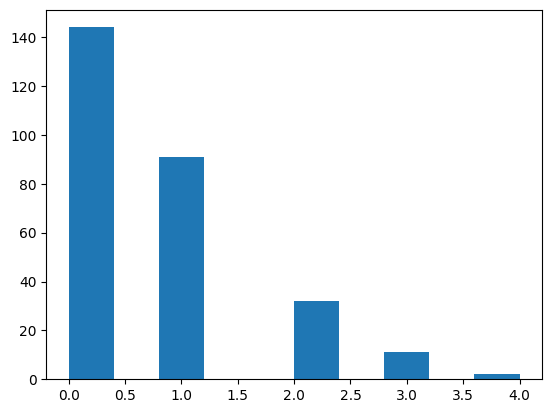

In [ ]:
y = np.loadtxt('/drive/MyDrive/COM3023/week1/Prussian-Horse-Kick-Data_Workshop.csv') #your path
plt.hist(y)
plt.show()

Likelihood function:
$$
    p(y|\lambda) \propto \prod_{i=1}^n \lambda^{y_i} \exp(-\lambda)
$$
$$
    p(y|\lambda) \propto \lambda^{\sum_{i=1}^n y_i} \exp(-n \lambda)
$$

Log-likelihood:
$$
    \log p(y|\lambda) \propto \sum_{i=1}^n y_i \log(\lambda) -n\lambda
$$

In [ ]:
def likelihood(theta,*args):
    n = len(y)
    L = np.sum(y)*np.log(theta) - theta*n
    return -L

In [ ]:
bounds = [(0.0001,100)]
x0 = [1]
results = minimize(likelihood,x0,args = (y),bounds = bounds, method = 'L-BFGS-B')

In [ ]:
print(results.x,results.fun)
#minimizing -L, a larger value of results.fun is better.

[0.7] 265.90828901199154


### Poisson Distribution and Log-Likelihood

The probability mass function (PMF) of the Poisson distribution is:

$$
p(y_i \mid \lambda) = \frac{\lambda^{y_i} e^{-\lambda}}{y_i!}
$$

Given \( $n$ \) independent observations \( $y_1, y_2, \dots, y_n$ \), the likelihood function is:

$$
L(\lambda) = \prod_{i=1}^{n} \frac{\lambda^{y_i} e^{-\lambda}}{y_i!}
$$

Taking the natural logarithm of the likelihood function:

$$
\log L(\lambda) = \log \left( \prod_{i=1}^{n} \frac{\lambda^{y_i} e^{-\lambda}}{y_i!} \right)
$$

Using the properties of logarithms, we can simplify:

$$
\log L(\lambda) = \sum_{i=1}^{n} \left( y_i \log(\lambda) - \lambda - \log(y_i!) \right)
$$

Since \( $\log(y_i!)$ \) does not depend on \( $\lambda$ \), we can ignore it when maximizing the likelihood. Therefore, the log-likelihood simplifies to:

$$
\log L(\lambda) \propto \sum_{i=1}^{n} y_i \log(\lambda) - n \lambda
$$

### Maximizing the Log-Likelihood

To find the Maximum Likelihood Estimate (MLE) for \( $\lambda$ \), we take the derivative of the log-likelihood with respect to \( $\lambda$ \) and set it equal to zero.

#### Derivative with respect to \( $\lambda$ \):

$$
\frac{\partial}{\partial \lambda} \left( \sum_{i=1}^{n} y_i \log(\lambda) - n \lambda \right) = \frac{\sum_{i=1}^{n} y_i}{\lambda} - n
$$

#### Setting the derivative equal to zero:

$$
\frac{\sum_{i=1}^{n} y_i}{\lambda} - n = 0
$$

Solving for \( \lambda \):

$$
\lambda = \frac{\sum_{i=1}^{n} y_i}{n}
$$

### Conclusion

The Maximum Likelihood Estimate (MLE) for \( $\lambda$ \) is:

$$
\hat{\lambda} = \frac{\sum_{i=1}^{n} y_i}{n}
$$
